<a href="https://colab.research.google.com/github/Dokkae-bi/Intro-to-DL-Summer-26/blob/main/Homework2/Homework_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Problem 1

In [1]:
# ===== Cell 1: Vocabulary + Encoding =====
import torch
import torch.nn as nn
import time

# --- Reproducibility ---
SEED = 42
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
import numpy as np
np.random.seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# The text provided in the assignment
text = """Next character prediction is a fundamental task in the field of natural language processing (NLP) that involves predicting the next character in a sequence of text based on the characters that precede it. This task is essential for various applications, including text auto-completion, spell checking, and even in the development of sophisticated AI models capable of generating human-like text.

At its core, next character prediction relies on statistical models or deep learning algorithms to analyze a given sequence of text and predict which character is most likely to follow. These predictions are based on patterns and relationships learned from large datasets of text during the training phase of the model.

One of the most popular approaches to next character prediction involves the use of Recurrent Neural Networks (RNNs), and more specifically, a variant called Long Short-Term Memory (LSTM) networks. RNNs are particularly well-suited for sequential data like text, as they can maintain information in 'memory' about previous characters to inform the prediction of the next character. LSTM networks enhance this capability by being able to remember long-term dependencies, making them even more effective for next character prediction tasks.

Training a model for next character prediction involves feeding it large amounts of text data, allowing it to learn the probability of each character's appearance following a sequence of characters. During this training process, the model adjusts its parameters to minimize the difference between its predictions and the actual outcomes, thus improving its predictive accuracy over time.

Once trained, the model can be used to predict the next character in a given piece of text by considering the sequence of characters that precede it. This can enhance user experience in text editing software, improve efficiency in coding environments with auto-completion features, and enable more natural interactions with AI-based chatbots and virtual assistants.

In summary, next character prediction plays a crucial role in enhancing the capabilities of various NLP applications, making text-based interactions more efficient, accurate, and human-like. Through the use of advanced machine learning models like RNNs and LSTMs, next character prediction continues to evolve, opening new possibilities for the future of text-based technology."""

# Build the vocabulary: every unique character, sorted for reproducibility
chars = sorted(set(text))
vocab_size = len(chars)

# Two-way mapping between characters and integer indices
char2idx = {ch: i for i, ch in enumerate(chars)}
idx2char = {i: ch for i, ch in enumerate(chars)}

# Encode the whole essay as a list of integers
encoded = [char2idx[ch] for ch in text]

# --- Sanity checks ---
print("Total characters in essay:", len(text))
print("Vocabulary size:", vocab_size)
print("Vocabulary:", chars)
print("First 20 chars  :", repr(text[:20]))
print("First 20 encoded:", encoded[:20])
decoded = ''.join(idx2char[i] for i in encoded[:20])
print("Round-trip OK   :", decoded == text[:20])

Device: cuda
Total characters in essay: 2391
Vocabulary size: 45
Vocabulary: ['\n', ' ', "'", '(', ')', ',', '-', '.', 'A', 'D', 'I', 'L', 'M', 'N', 'O', 'P', 'R', 'S', 'T', 'a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'w', 'x', 'y', 'z']
First 20 chars  : 'Next character predi'
First 20 encoded: [13, 23, 42, 38, 1, 21, 26, 19, 36, 19, 21, 38, 23, 36, 1, 34, 36, 23, 22, 27]
Round-trip OK   : True


In [2]:
# ===== Cell 2: Build training tensors (sliding windows + one-hot) =====

def build_dataset(encoded, seq_length, vocab_size, device):
    """
    Slide a window of `seq_length` over the encoded essay.
    Input  X: one-hot, shape (num_sequences, seq_length, vocab_size)
    Label  y: integer index of the next char, shape (num_sequences,)
    """
    X_idx, y = [], []
    L = len(encoded)
    for i in range(L - seq_length):
        X_idx.append(encoded[i : i + seq_length])   # the context window
        y.append(encoded[i + seq_length])           # the single next char
    X_idx = torch.tensor(X_idx, dtype=torch.long)    # (N, seq_length)
    y = torch.tensor(y, dtype=torch.long)            # (N,)

    # Turn each index into a one-hot row of length vocab_size
    X = torch.nn.functional.one_hot(X_idx, num_classes=vocab_size).float()
    return X.to(device), y.to(device)

# Build all three datasets we'll need for Problem 1
datasets = {}
for sl in [10, 20, 30]:
    X, y = build_dataset(encoded, sl, vocab_size, device)
    datasets[sl] = (X, y)
    print(f"seq_length={sl:2d}:  X={tuple(X.shape)}  y={tuple(y.shape)}  ({X.shape[0]} sequences)")

# --- Sanity check: look at one concrete example ---
X10, y10 = datasets[10]
first_window = ''.join(idx2char[i.item()] for i in X10[0].argmax(dim=1))
print("\nFirst window (seq_length=10):", repr(first_window))
print("Its label index:", y10[0].item(), "-> char", repr(idx2char[y10[0].item()]))
print("One-hot row sums (all should be 1):", X10[0].sum(dim=1).tolist())

seq_length=10:  X=(2381, 10, 45)  y=(2381,)  (2381 sequences)
seq_length=20:  X=(2371, 20, 45)  y=(2371,)  (2371 sequences)
seq_length=30:  X=(2361, 30, 45)  y=(2361,)  (2361 sequences)

First window (seq_length=10): 'Next chara'
Its label index: 21 -> char 'c'
One-hot row sums (all should be 1): [1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0]


In [3]:
# ===== Cell 3: The model — one class, switchable between RNN / LSTM / GRU =====

class CharModel(nn.Module):
    def __init__(self, model_type, input_size, hidden_size, output_size, num_layers=1):
        super().__init__()
        self.model_type = model_type.lower()
        # All three share the same constructor signature
        rnn_cls = {'rnn': nn.RNN, 'lstm': nn.LSTM, 'gru': nn.GRU}[self.model_type]
        self.rnn = rnn_cls(input_size, hidden_size,
                           num_layers=num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        out, _ = self.rnn(x)
        out = self.fc(out[:, -1, :])
        return out

def count_params(model):
    return sum(p.numel() for p in model.parameters())

# --- Sanity check: instantiate all three and compare size ---
hidden_size = 128

for mt in ['rnn', 'lstm', 'gru']:
    m = CharModel(mt, vocab_size, hidden_size, vocab_size).to(device)
    n = count_params(m)
    print(f"{mt.upper():4s}: {n:,} params  (~{n*4/1024:.1f} KB)")

RNN : 28,205 params  (~110.2 KB)
LSTM: 95,405 params  (~372.7 KB)
GRU : 73,005 params  (~285.2 KB)


In [4]:
# ===== Cell 4: Train + validate one configuration (corrected) =====

def train_eval(model_type, seq_length, hidden_size=128, epochs=100,
               lr=0.005, batch_size=64, clip=1.0, verbose=True):
    torch.manual_seed(SEED)
    X, y = build_dataset(encoded, seq_length, vocab_size, device)
    N = X.shape[0]

    model = CharModel(model_type, vocab_size, hidden_size, vocab_size).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    loss_history = []
    best_loss = float('inf')          # initialize before the loop
    start = time.time()
    for epoch in range(epochs):
        model.train()
        perm = torch.randperm(N, device=device)
        epoch_loss = 0.0
        for i in range(0, N, batch_size):
            idx = perm[i:i+batch_size]
            xb, yb = X[idx], y[idx]
            optimizer.zero_grad()
            logits = model(xb)
            loss = criterion(logits, yb)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), clip)   # gradient clipping
            optimizer.step()
            epoch_loss += loss.item() * xb.size(0)
        epoch_loss /= N
        loss_history.append(epoch_loss)
        best_loss = min(best_loss, epoch_loss)                          # track best epoch
        if verbose and epoch % 20 == 0:
            print(f"  epoch {epoch:3d}  loss {epoch_loss:.4f}")
    train_time = time.time() - start

    model.eval()
    with torch.no_grad():
        preds = model(X).argmax(dim=1)
        val_acc = (preds == y).float().mean().item()

    return {
        'model': model_type, 'seq': seq_length,
        'final_loss': loss_history[-1], 'best_loss': best_loss,
        'val_acc': val_acc, 'time': train_time,
        'params': count_params(model), 'loss_history': loss_history,
    }

# --- Test on one config ---
result = train_eval('gru', 20, verbose=True)
print(result['model'], result['seq'],
      f"acc={result['val_acc']:.3f}", f"loss={result['final_loss']:.4f}",
      f"best={result['best_loss']:.4f}")

  epoch   0  loss 3.1525
  epoch  20  loss 0.1265
  epoch  40  loss 0.0149
  epoch  60  loss 0.0128
  epoch  80  loss 0.0129
gru 20 acc=0.995 loss=0.0626 best=0.0113


In [5]:
# ===== Cell 5: Run all 9 configurations (3 models x 3 sequence lengths) =====

results = []
for sl in [10, 20, 30]:
    for mt in ['rnn', 'lstm', 'gru']:
        print(f"Training {mt.upper()} @ seq_length={sl} ...")
        r = train_eval(mt, sl, hidden_size=128, epochs=100,
                       lr=0.005, batch_size=64, verbose=False)
        results.append(r)

# --- Results table ---
print(f"\n{'model':5s} {'seq':>3s} {'params':>8s} {'KB':>7s} "
      f"{'final':>7s} {'best':>7s} {'acc':>6s} {'time_s':>7s}")
for r in results:
    print(f"{r['model'].upper():5s} {r['seq']:>3d} {r['params']:>8,d} "
          f"{r['params']*4/1024:>6.1f} {r['final_loss']:>7.3f} "
          f"{r['best_loss']:>7.3f} {r['val_acc']:>6.3f} {r['time']:>7.1f}")

Training RNN @ seq_length=10 ...
Training LSTM @ seq_length=10 ...
Training GRU @ seq_length=10 ...
Training RNN @ seq_length=20 ...
Training LSTM @ seq_length=20 ...
Training GRU @ seq_length=20 ...
Training RNN @ seq_length=30 ...
Training LSTM @ seq_length=30 ...
Training GRU @ seq_length=30 ...

model seq   params      KB   final    best    acc  time_s
RNN    10   28,205  110.2   0.277   0.220  0.943     7.6
LSTM   10   95,405  372.7   0.055   0.050  0.980     8.6
GRU    10   73,005  285.2   0.053   0.052  0.980     8.2
RNN    20   28,205  110.2   0.454   0.291  0.856     7.8
LSTM   20   95,405  372.7   0.013   0.013  0.996     8.4
GRU    20   73,005  285.2   0.063   0.011  0.995     8.1
RNN    30   28,205  110.2   3.157   0.262  0.224     7.3
LSTM   30   95,405  372.7   0.006   0.006  0.998     8.1
GRU    30   73,005  285.2   0.101   0.005  0.986     7.7


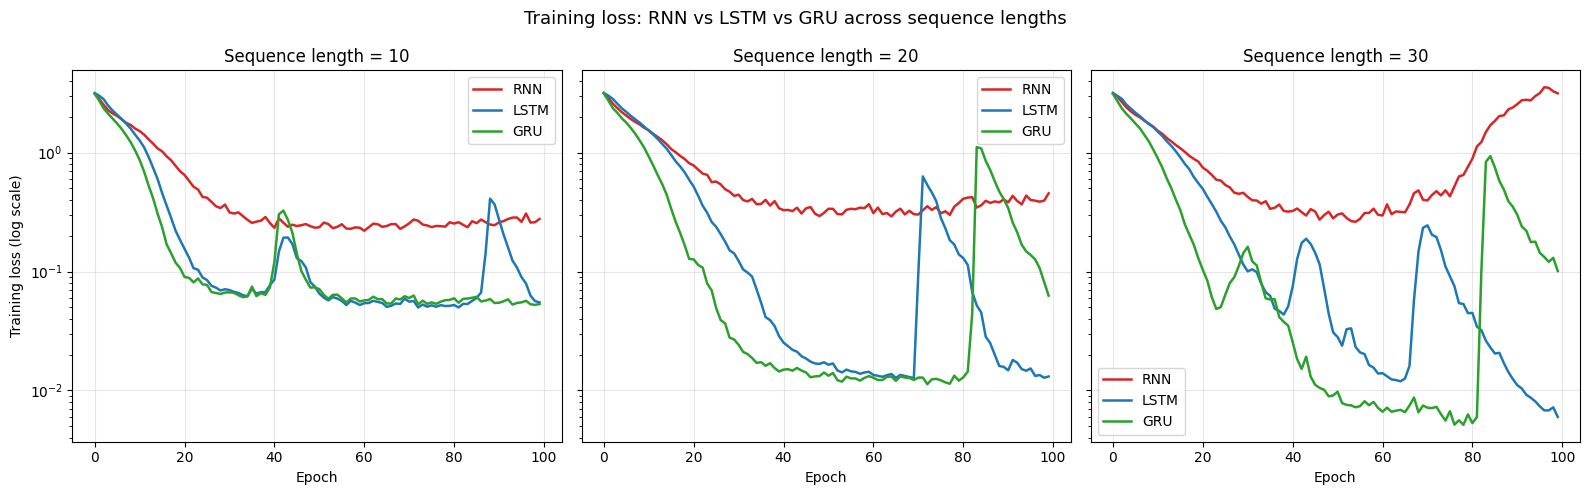

In [6]:
# ===== Cell 6: Plot the 9 loss curves =====
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)
colors = {'rnn': 'tab:red', 'lstm': 'tab:blue', 'gru': 'tab:green'}

for ax, sl in zip(axes, [10, 20, 30]):
    for r in results:
        if r['seq'] == sl:
            ax.plot(r['loss_history'], label=r['model'].upper(),
                    color=colors[r['model']], linewidth=1.8)
    ax.set_title(f"Sequence length = {sl}")
    ax.set_xlabel("Epoch")
    ax.set_yscale('log')              # log scale: the dive to ~0 is the whole story
    ax.grid(True, alpha=0.3)
    ax.legend()

axes[0].set_ylabel("Training loss (log scale)")
fig.suptitle("Training loss: RNN vs LSTM vs GRU across sequence lengths", fontsize=13)
plt.tight_layout()
plt.savefig("problem1_loss_curves.png", dpi=150, bbox_inches='tight')
plt.show()

In [7]:
# ===== Cell 7: Text generation (autoregressive sampling) =====

def generate(model, seed_str, length=200, temperature=1.0):
    """Feed a seed string, then roll forward generating `length` characters."""
    model.eval()
    # encode the seed; if it's shorter than what the model expects, that's fine—
    # the RNN handles variable-length input, we just keep a growing context window
    context = [char2idx[c] for c in seed_str]
    generated = seed_str
    with torch.no_grad():
        for _ in range(length):
            # use the last `seq_window` chars as context
            x = torch.nn.functional.one_hot(
                    torch.tensor(context, device=device), vocab_size
                ).float().unsqueeze(0)
            logits = model(x)[0] / temperature
            probs = torch.softmax(logits, dim=0)
            nxt = torch.multinomial(probs, 1).item()
            generated += idx2char[nxt]
            context.append(nxt)
    return generated

# Train one fresh model per type at seq_length=20 and generate from each
seed = "Next character pred" + "tion"[0]   # "Next character predi" -> 20 chars
seed = "Next character predi"               # exactly 20 chars

print(f'SEED: "{seed}"\n' + "="*70)
for mt in ['rnn', 'lstm', 'gru']:
    torch.manual_seed(SEED)
    X, y = build_dataset(encoded, 20, vocab_size, device)
    model = CharModel(mt, vocab_size, 128, vocab_size).to(device)
    crit = nn.CrossEntropyLoss(); opt = torch.optim.Adam(model.parameters(), lr=0.005)
    for ep in range(100):
        perm = torch.randperm(X.shape[0], device=device)
        for i in range(0, X.shape[0], 64):
            idx = perm[i:i+64]
            opt.zero_grad()
            loss = crit(model(X[idx]), y[idx]); loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0); opt.step()

    out = generate(model, seed, length=180, temperature=0.8)
    print(f"\n[{mt.upper()}]")
    print(out)

SEED: "Next character predi"

[RNN]
Next character prediction tasks.

T-sese os toxt date, and the characters.

On e hasg, and even softvare, acturn, andencin mastous of nhatvepsediction iss predictive fuldory in even ies esen ien in th

[LSTM]
Next character prediction continues to evolve, opening new possibilities for the future of text-based cene apllar approaches to next character is most likely to follow. These prediction relies on stat

[GRU]
Next character predict which character. LSTM networks enhance the deet, accuracter is most like text during the training in the fuediting the characters that precede it. This can enhance tial outcomes


Problem 2

In [8]:
# ===== Problem 2 — Cell 1: Tiny Shakespeare loader (professor's code) =====
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import numpy as np
import requests
import time

SEED = 42
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# Step 1: Download the dataset
url = "https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt"
response = requests.get(url)
text = response.text

# Step 2: Vocabulary + encoding
sequence_length = 20
chars = sorted(list(set(text)))
vocab_size = len(chars)
char_to_int = {ch: i for i, ch in enumerate(chars)}
int_to_char = {i: ch for i, ch in enumerate(chars)}
encoded_text = [char_to_int[ch] for ch in text]

print("Total characters:", len(text))
print("Vocabulary size:", vocab_size)

# Step 3: Sliding windows
sequences, targets = [], []
for i in range(0, len(encoded_text) - sequence_length):
    sequences.append(encoded_text[i:i+sequence_length])
    targets.append(encoded_text[i+sequence_length])
sequences = torch.tensor(sequences, dtype=torch.long)
targets = torch.tensor(targets, dtype=torch.long)

# Step 4: Dataset + split + loaders
class CharDataset(Dataset):
    def __init__(self, sequences, targets):
        self.sequences = sequences
        self.targets = targets
    def __len__(self):
        return len(self.sequences)
    def __getitem__(self, index):
        return self.sequences[index], self.targets[index]

dataset = CharDataset(sequences, targets)
batch_size = 128
train_size = int(len(dataset) * 0.8)
test_size = len(dataset) - train_size
train_dataset, test_dataset = torch.utils.data.random_split(
    dataset, [train_size, test_size],
    generator=torch.Generator().manual_seed(SEED))     # reproducible split
train_loader = DataLoader(train_dataset, shuffle=True, batch_size=batch_size)
test_loader = DataLoader(test_dataset, shuffle=False, batch_size=batch_size)

print(f"Train windows: {train_size:,}   Test windows: {test_size:,}")

Device: cuda
Total characters: 1115394
Vocabulary size: 65
Train windows: 892,299   Test windows: 223,075


In [9]:
# ===== Problem 2 — Cell 2: Model (with embedding) + train/eval =====
import math

class CharModelEmb(nn.Module):
    def __init__(self, model_type, vocab_size, embed_dim, hidden_size,
                 num_layers=1, fc_hidden=None):
        super().__init__()
        self.embed = nn.Embedding(vocab_size, embed_dim)
        rnn_cls = {'rnn': nn.RNN, 'lstm': nn.LSTM, 'gru': nn.GRU}[model_type.lower()]
        self.rnn = rnn_cls(embed_dim, hidden_size,
                           num_layers=num_layers, batch_first=True)
        if fc_hidden is None:
            self.fc = nn.Linear(hidden_size, vocab_size)
        else:
            self.fc = nn.Sequential(
                nn.Linear(hidden_size, fc_hidden),
                nn.ReLU(),
                nn.Linear(fc_hidden, vocab_size))

    def forward(self, x):
        x = self.embed(x)
        out, _ = self.rnn(x)
        return self.fc(out[:, -1, :])

def count_params(model):
    return sum(p.numel() for p in model.parameters())

@torch.no_grad()
def evaluate(model, loader):
    """Average loss and next-char accuracy over a loader (test set)."""
    model.eval()
    crit = nn.CrossEntropyLoss()
    total_loss, correct, total = 0.0, 0, 0
    for seq, target in loader:
        seq, target = seq.to(device), target.to(device)
        logits = model(seq)
        total_loss += crit(logits, target).item() * seq.size(0)
        correct += (logits.argmax(1) == target).sum().item()
        total += seq.size(0)
    return total_loss / total, correct / total

def train_eval_p2(model_type, train_loader, test_loader, vocab_size,
                  embed_dim=32, hidden_size=128, num_layers=1, fc_hidden=None,
                  epochs=5, lr=0.002, clip=1.0, verbose=True):
    torch.manual_seed(SEED)
    model = CharModelEmb(model_type, vocab_size, embed_dim,
                         hidden_size, num_layers, fc_hidden).to(device)
    crit = nn.CrossEntropyLoss()
    opt = torch.optim.Adam(model.parameters(), lr=lr)

    start = time.time()
    for epoch in range(epochs):
        model.train()
        running, seen = 0.0, 0
        for seq, target in train_loader:
            seq, target = seq.to(device), target.to(device)
            opt.zero_grad()
            loss = crit(model(seq), target)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), clip)
            opt.step()
            running += loss.item() * seq.size(0); seen += seq.size(0)
        train_loss = running / seen
        test_loss, test_acc = evaluate(model, test_loader)
        if verbose:
            print(f"  epoch {epoch+1:2d}  train_loss {train_loss:.4f}  "
                  f"test_loss {test_loss:.4f}  test_acc {test_acc:.4f}")
    train_time = time.time() - start

    return {
        'model': model_type, 'train_loss': train_loss,
        'test_loss': test_loss, 'test_acc': test_acc,
        'perplexity': math.exp(test_loss),
        'time': train_time, 'params': count_params(model),
    }

# --- Quick test: GRU, a couple of epochs, to confirm it runs and learns ---
result = train_eval_p2('gru', train_loader, test_loader, vocab_size, epochs=3)
print(result['model'], f"test_acc={result['test_acc']:.4f}",
      f"params={result['params']:,}", f"time={result['time']:.1f}s")

  epoch  1  train_loss 1.7732  test_loss 1.6132  test_acc 0.5180
  epoch  2  train_loss 1.5612  test_loss 1.5538  test_acc 0.5337
  epoch  3  train_loss 1.5197  test_loss 1.5340  test_acc 0.5388
gru test_acc=0.5388 params=72,673 time=70.6s


In [10]:
# ===== Problem 2 — Cell 3: make_loaders helper + core sweep =====

class CharDataset(Dataset):
    def __init__(self, sequences, targets):
        self.sequences = sequences
        self.targets = targets
    def __len__(self):
        return len(self.sequences)
    def __getitem__(self, index):
        return self.sequences[index], self.targets[index]

def make_loaders(seq_length, batch_size=128):
    """Rebuild windows + split + loaders for a given sequence length."""
    seqs, tgts = [], []
    for i in range(0, len(encoded_text) - seq_length):
        seqs.append(encoded_text[i:i+seq_length])
        tgts.append(encoded_text[i+seq_length])
    seqs = torch.tensor(seqs, dtype=torch.long)
    tgts = torch.tensor(tgts, dtype=torch.long)
    ds = CharDataset(seqs, tgts)
    train_size = int(len(ds) * 0.8)
    test_size = len(ds) - train_size
    train_ds, test_ds = torch.utils.data.random_split(
        ds, [train_size, test_size],
        generator=torch.Generator().manual_seed(SEED))
    train_loader = DataLoader(train_ds, shuffle=True, batch_size=batch_size)
    test_loader  = DataLoader(test_ds, shuffle=False, batch_size=batch_size)
    return train_loader, test_loader

# --- Run LSTM and GRU at seq lengths 20 and 30 (5 epochs each) ---
p2_results = []
for sl in [20, 30]:
    train_loader, test_loader = make_loaders(sl)
    for mt in ['lstm', 'gru']:
        print(f"\n=== {mt.upper()} @ seq_length={sl} ===")
        r = train_eval_p2(mt, train_loader, test_loader, vocab_size,
                          embed_dim=32, hidden_size=128, num_layers=1,
                          epochs=5, lr=0.002, verbose=True)
        r['seq'] = sl   # tag with the actual length used
        p2_results.append(r)

# --- Results table ---
print(f"\n{'model':5s} {'seq':>3s} {'params':>8s} {'train_loss':>10s} "
      f"{'test_acc':>9s} {'time_s':>7s}")
for r in p2_results:
    print(f"{r['model'].upper():5s} {r['seq']:>3d} {r['params']:>8,d} "
          f"{r['train_loss']:>10.4f} {r['test_acc']:>9.4f} {r['time']:>7.1f}")


=== LSTM @ seq_length=20 ===
  epoch  1  train_loss 1.8148  test_loss 1.6088  test_acc 0.5199
  epoch  2  train_loss 1.5508  test_loss 1.5287  test_acc 0.5402
  epoch  3  train_loss 1.4914  test_loss 1.4929  test_acc 0.5484
  epoch  4  train_loss 1.4602  test_loss 1.4763  test_acc 0.5502
  epoch  5  train_loss 1.4397  test_loss 1.4625  test_acc 0.5553

=== GRU @ seq_length=20 ===
  epoch  1  train_loss 1.7732  test_loss 1.6132  test_acc 0.5180
  epoch  2  train_loss 1.5612  test_loss 1.5538  test_acc 0.5337
  epoch  3  train_loss 1.5197  test_loss 1.5340  test_acc 0.5388
  epoch  4  train_loss 1.4996  test_loss 1.5129  test_acc 0.5453
  epoch  5  train_loss 1.4878  test_loss 1.5059  test_acc 0.5473

=== LSTM @ seq_length=30 ===
  epoch  1  train_loss 1.8154  test_loss 1.6119  test_acc 0.5195
  epoch  2  train_loss 1.5493  test_loss 1.5294  test_acc 0.5397
  epoch  3  train_loss 1.4886  test_loss 1.4924  test_acc 0.5503
  epoch  4  train_loss 1.4567  test_loss 1.4771  test_acc 0.5524
 

In [11]:
# ===== Problem 2 — Cell 4: Hyperparameter sweep (both models) =====
SWEEP_SEQ = 20
train_loader, test_loader = make_loaders(SWEEP_SEQ)

sweep_configs = [
    ('baseline (h=128, L=1, simple FC)', dict(hidden_size=128, num_layers=1, fc_hidden=None)),
    ('wider (h=256, L=1)',               dict(hidden_size=256, num_layers=1, fc_hidden=None)),
    ('deeper (h=128, L=2)',              dict(hidden_size=128, num_layers=2, fc_hidden=None)),
    ('FC head (h=128, L=1, 128->128)',   dict(hidden_size=128, num_layers=1, fc_hidden=128)),
]

sweep_results = []
for mt in ['lstm', 'gru']:
    for label, cfg in sweep_configs:
        print(f"\n=== {mt.upper()} | {label} ===")
        r = train_eval_p2(mt, train_loader, test_loader, vocab_size,
                          embed_dim=32, epochs=5, lr=0.002, verbose=True, **cfg)
        r['label'] = label
        sweep_results.append(r)

# --- Sweep results table ---
print(f"\n{'model':5s} {'config':34s} {'params':>8s} {'tr_loss':>8s} "
      f"{'test_acc':>9s} {'perplx':>7s} {'time_s':>7s}")
for r in sweep_results:
    print(f"{r['model'].upper():5s} {r['label']:34s} {r['params']:>8,d} "
          f"{r['train_loss']:>8.4f} {r['test_acc']:>9.4f} "
          f"{r['perplexity']:>7.3f} {r['time']:>7.1f}")


=== LSTM | baseline (h=128, L=1, simple FC) ===
  epoch  1  train_loss 1.8148  test_loss 1.6088  test_acc 0.5199
  epoch  2  train_loss 1.5508  test_loss 1.5287  test_acc 0.5402
  epoch  3  train_loss 1.4914  test_loss 1.4929  test_acc 0.5484
  epoch  4  train_loss 1.4602  test_loss 1.4763  test_acc 0.5502
  epoch  5  train_loss 1.4397  test_loss 1.4625  test_acc 0.5553

=== LSTM | wider (h=256, L=1) ===
  epoch  1  train_loss 1.6947  test_loss 1.5018  test_acc 0.5450
  epoch  2  train_loss 1.4445  test_loss 1.4297  test_acc 0.5652
  epoch  3  train_loss 1.3881  test_loss 1.4066  test_acc 0.5694
  epoch  4  train_loss 1.3584  test_loss 1.3957  test_acc 0.5726
  epoch  5  train_loss 1.3404  test_loss 1.3864  test_acc 0.5750

=== LSTM | deeper (h=128, L=2) ===
  epoch  1  train_loss 1.7703  test_loss 1.5554  test_acc 0.5320
  epoch  2  train_loss 1.4921  test_loss 1.4744  test_acc 0.5515
  epoch  3  train_loss 1.4302  test_loss 1.4387  test_acc 0.5603
  epoch  4  train_loss 1.3987  test

In [12]:
# ===== Problem 2 — Cell 5: Sequence length 50 =====
train_loader_50, test_loader_50 = make_loaders(50)

len50_results = []
for mt in ['lstm', 'gru']:
    print(f"=== {mt.upper()} @ seq_length=50 ===")
    r = train_eval_p2(mt, train_loader_50, test_loader_50, vocab_size,
                      embed_dim=32, hidden_size=128, num_layers=1, fc_hidden=None,
                      epochs=5, lr=0.002, verbose=True)
    r['seq'] = 50
    len50_results.append(r)

print(f"\n{'model':5s} {'seq':>3s} {'params':>8s} {'test_acc':>9s} "
      f"{'perplx':>7s} {'time_s':>7s}")
for r in len50_results:
    print(f"{r['model'].upper():5s} {r['seq']:>3d} {r['params']:>8,d} "
          f"{r['test_acc']:>9.4f} {r['perplexity']:>7.3f} {r['time']:>7.1f}")

=== LSTM @ seq_length=50 ===
  epoch  1  train_loss 1.8038  test_loss 1.5985  test_acc 0.5206
  epoch  2  train_loss 1.5391  test_loss 1.5149  test_acc 0.5428
  epoch  3  train_loss 1.4771  test_loss 1.4785  test_acc 0.5526
  epoch  4  train_loss 1.4447  test_loss 1.4586  test_acc 0.5571
  epoch  5  train_loss 1.4239  test_loss 1.4491  test_acc 0.5598
=== GRU @ seq_length=50 ===
  epoch  1  train_loss 1.7596  test_loss 1.5948  test_acc 0.5223
  epoch  2  train_loss 1.5449  test_loss 1.5439  test_acc 0.5349
  epoch  3  train_loss 1.5025  test_loss 1.5147  test_acc 0.5453
  epoch  4  train_loss 1.4821  test_loss 1.5084  test_acc 0.5464
  epoch  5  train_loss 1.4703  test_loss 1.4916  test_acc 0.5481

model seq   params  test_acc  perplx  time_s
LSTM   50   93,409    0.5598   4.259   129.9
GRU    50   72,673    0.5481   4.444   126.0


In [13]:
# ===== Problem 2 — Cell 6: Generate Shakespeare =====

@torch.no_grad()
def generate_shakespeare(model, seed_str, length=500, temperature=0.8, context_len=30):
    model.eval()
    context = [char_to_int[c] for c in seed_str]
    generated = seed_str
    for _ in range(length):
        x = torch.tensor(context[-context_len:], device=device).unsqueeze(0)  # (1, L)
        logits = model(x)[0] / temperature
        probs = torch.softmax(logits, dim=0)
        nxt = torch.multinomial(probs, 1).item()
        generated += int_to_char[nxt]
        context.append(nxt)
    return generated

# --- Train a strong model for generation (LSTM, h=256) ---
GEN_SEQ = 30
torch.manual_seed(SEED)
train_loader_gen, _ = make_loaders(GEN_SEQ)
gen_model = CharModelEmb('lstm', vocab_size, embed_dim=32,
                         hidden_size=256, num_layers=1).to(device)
crit = nn.CrossEntropyLoss()
opt = torch.optim.Adam(gen_model.parameters(), lr=0.002)

GEN_EPOCHS = 6
for epoch in range(GEN_EPOCHS):
    gen_model.train()
    for seq, target in train_loader_gen:
        seq, target = seq.to(device), target.to(device)
        opt.zero_grad()
        loss = crit(gen_model(seq), target)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(gen_model.parameters(), 1.0)
        opt.step()
    print(f"epoch {epoch+1}/{GEN_EPOCHS} done")

# --- Sample at a few temperatures from the same seed ---
seed = "ROMEO:"
for temp in [0.5, 0.8, 1.0]:
    print(f"\n{'='*60}\nTEMPERATURE = {temp}\n{'='*60}")
    print(generate_shakespeare(gen_model, seed, length=500,
                               temperature=temp, context_len=GEN_SEQ))

epoch 1/6 done
epoch 2/6 done
epoch 3/6 done
epoch 4/6 done
epoch 5/6 done
epoch 6/6 done

TEMPERATURE = 0.5
ROMEO:
The good state to marry, and there all my wife,
And there and the people be well,
And he shall have not in the common bed
In this thy brother's present that he did make thee hand.

First Servant:
I am a word with their very sight.

ROMEO:
Marry, good news, sir; therefore destruction that I cannot speak to thee,
Which did seem to be not hers and all my heart
To seek in the winders of the law;
The worst now the service, sir.

PETRUCHIO:
And this man thou art the crown and the lands,
I dare not ha

TEMPERATURE = 0.8
ROMEO:
And from he is hubbine thou may'st a taily;
Thy dear whilst I say; son and tarder for the king,
That he hath made the gods and kiss,
Since thither; I can tell us, and yet let me be cruel England;
Is all her by his grace, but now dally;
What ride, my son?

HENRY PERCINE:
Come, I think only company it: they can much me?
Saint, ere this child.

Servant:
And t

In [14]:
# ===== Problem 2 — Cell 7: Inference time across sweep configs =====
import time

# Inference time depends on architecture (hidden size, layers, FC head), not on
# the trained weights, since a forward pass does the same arithmetic either way.
# So we build each config and time a no-grad forward pass over the test set.

infer_seq = 20
_, infer_test_loader = make_loaders(infer_seq)

infer_configs = [
    ('LSTM baseline (h=128, L=1)', 'lstm', dict(hidden_size=128, num_layers=1, fc_hidden=None)),
    ('LSTM wider (h=256, L=1)',    'lstm', dict(hidden_size=256, num_layers=1, fc_hidden=None)),
    ('LSTM deeper (h=128, L=2)',   'lstm', dict(hidden_size=128, num_layers=2, fc_hidden=None)),
    ('LSTM FC head (128->128)',    'lstm', dict(hidden_size=128, num_layers=1, fc_hidden=128)),
    ('GRU baseline (h=128, L=1)',  'gru',  dict(hidden_size=128, num_layers=1, fc_hidden=None)),
    ('GRU wider (h=256, L=1)',     'gru',  dict(hidden_size=256, num_layers=1, fc_hidden=None)),
    ('GRU deeper (h=128, L=2)',    'gru',  dict(hidden_size=128, num_layers=2, fc_hidden=None)),
    ('GRU FC head (128->128)',     'gru',  dict(hidden_size=128, num_layers=1, fc_hidden=128)),
]

@torch.no_grad()
def measure_inference_time(model, loader, max_batches=300):
    model.eval()
    # warm-up: first CUDA calls include one-time setup overhead
    for seq, _ in loader:
        model(seq.to(device)); break
    if device.type == 'cuda':
        torch.cuda.synchronize()
    start = time.time()
    n = 0
    for seq, _ in loader:
        model(seq.to(device))
        n += 1
        if n >= max_batches:
            break
    if device.type == 'cuda':
        torch.cuda.synchronize()
    return time.time() - start, n

print(f"{'config':30s} {'params':>8s} {'infer_s':>8s} {'ms/batch':>9s}")
for label, mt, cfg in infer_configs:
    model = CharModelEmb(mt, vocab_size, 32, **cfg).to(device)
    total, nb = measure_inference_time(model, infer_test_loader)
    print(f"{label:30s} {count_params(model):>8,d} {total:>8.3f} {total/nb*1000:>9.3f}")

config                           params  infer_s  ms/batch
LSTM baseline (h=128, L=1)       93,409    0.333     1.109
LSTM wider (h=256, L=1)         315,745    0.407     1.358
LSTM deeper (h=128, L=2)        225,505    0.360     1.200
LSTM FC head (128->128)         109,921    0.354     1.181
GRU baseline (h=128, L=1)        72,673    0.331     1.103
GRU wider (h=256, L=1)          241,505    0.401     1.337
GRU deeper (h=128, L=2)         171,745    0.334     1.114
GRU FC head (128->128)           89,185    0.350     1.167


In [15]:
# ===== Problem 2 — Cell 8: Output sequence — baseline vs wider =====
# Does the extra capacity that helped accuracy also produce better generated text?
# We train an h=128 and an h=256 LSTM and generate from each, same seed & temperature.

GEN_SEQ2 = 20
gen_train_loader, _ = make_loaders(GEN_SEQ2)

def train_for_gen(hidden_size, epochs=5):
    torch.manual_seed(SEED)
    model = CharModelEmb('lstm', vocab_size, 32, hidden_size, num_layers=1).to(device)
    crit = nn.CrossEntropyLoss()
    opt = torch.optim.Adam(model.parameters(), lr=0.002)
    for ep in range(epochs):
        model.train()
        for seq, target in gen_train_loader:
            seq, target = seq.to(device), target.to(device)
            opt.zero_grad()
            loss = crit(model(seq), target)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()
        print(f"  h={hidden_size}: epoch {ep+1}/{epochs} done")
    return model

seed_text = "ROMEO:"
for hsz, name in [(128, 'BASELINE (h=128)'), (256, 'WIDER (h=256)')]:
    print(f"\nTraining {name}...")
    m = train_for_gen(hsz)
    print(f"{'='*60}\n{name} — generated text (temperature 0.8)\n{'='*60}")
    print(generate_shakespeare(m, seed_text, length=400, temperature=0.8, context_len=GEN_SEQ2))


Training BASELINE (h=128)...
  h=128: epoch 1/5 done
  h=128: epoch 2/5 done
  h=128: epoch 3/5 done
  h=128: epoch 4/5 done
  h=128: epoch 5/5 done
BASELINE (h=128) — generated text (temperature 0.8)
ROMEO:

BENVOLIO:
Non's servant of distress,
Seem consul you me, and be lap with consent,
And prevailed than you do not did formance of what
behind mean the rest that we be changed have he is well:
But his subject a man,
Were the honour, what's my lord,
To her last of thousand sleetless and his sond well, thou tears, and ford philling men;
Let you are all Henry, we do?

PETRUCHIO:
Beet serve a lord, and

Training WIDER (h=256)...
  h=256: epoch 1/5 done
  h=256: epoch 2/5 done
  h=256: epoch 3/5 done
  h=256: epoch 4/5 done
  h=256: epoch 5/5 done
WIDER (h=256) — generated text (temperature 0.8)
ROMEO:

BENVOLINA:
In the god upon this love: but consulse them,
And be lack'd to the strong.

Provent:
Go, if it is it.

PETRUCHIO:
Fight, I'll have a better than great fool,
And should do wine 